In [1]:
import pandas as pd

df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
df.info()

df.isnull().sum()

df.duplicated().sum()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [3]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [4]:

num_df = df.select_dtypes(include=['int64', 'float64'])

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


mask = ~((num_df < lower_bound) | (num_df > upper_bound)).any(axis=1)

df = df[mask]

In [5]:
from sklearn.preprocessing import MinMaxScaler

num_df = df.select_dtypes(include=['int64', 'float64'])

minmax = MinMaxScaler()
df_minmax = minmax.fit_transform(num_df)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_zscore = scaler.fit_transform(num_df)

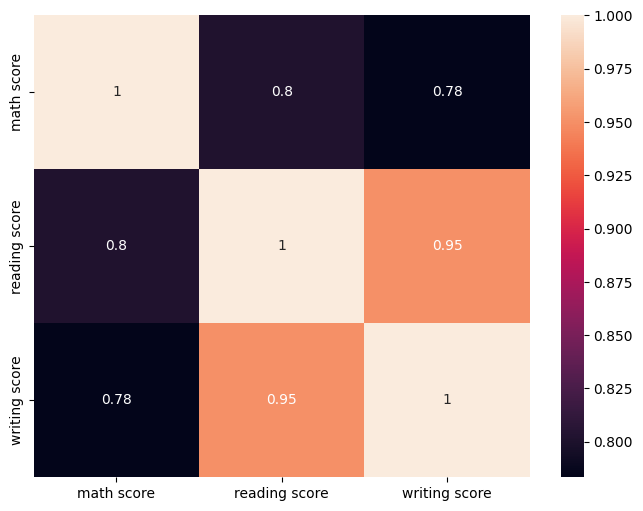

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True)
plt.show()

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_zscore)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.89752074 0.08620894]


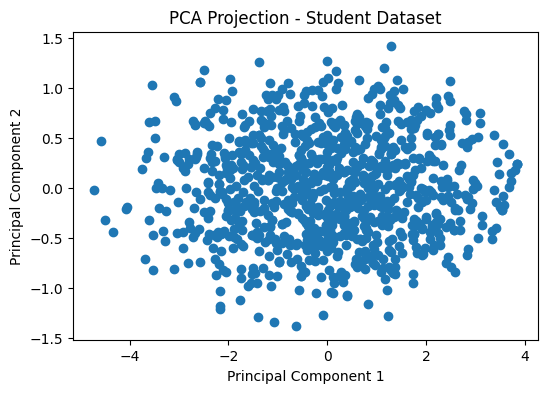

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


num_df = df.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection - Student Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()